In [1]:
import os
os.makedirs('/workspace/768265fc-c2a2-4bbe-9ded-7d7a15a1e3d1/data', exist_ok=True)
os.chdir('/workspace/768265fc-c2a2-4bbe-9ded-7d7a15a1e3d1')
print(os.getcwd())


/workspace/768265fc-c2a2-4bbe-9ded-7d7a15a1e3d1


In [2]:

# Plan:
# 1. Obtain ~10^6 nontrivial Riemann zeros. Odlyzko hosts these. Try LMFDB API or Odlyzko's site.
# 2. Compute pairwise gaps; due to memory, restrict pairs to gaps <= some max (say c <= 30).
# 3. Build histogram of gaps; look for spikes.
# 4. For top spikes, check growth N(T) vs T.
# 5. Compare to GUE-derived predicted pair correlation R_2(s) = 1 - (sin(pi s)/(pi s))^2 (with unfolded zeros).
#    For unfolded zeros, the local mean spacing is 1, and the pair-correlation function has no delta spikes (Montgomery).
# 6. Conclude.

# Step 1: Download zeros. Odlyzko provides zeros1.txt (first 10^5) and zeros2.txt etc. but they are not all readily available.
# LMFDB has zeros via API. Let me try the LMFDB API for zeta zeros.

import urllib.request
# Try lmfdb beta API
url = "https://www.lmfdb.org/zeros/zeta/?N=1&start=0&end=10"
try:
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=30) as r:
        data = r.read(2000).decode()
    print(data[:1500])
except Exception as e:
    print("err", e)


<!DOCTYPE html>
<html lang="en">
  <head>
    <meta http-equiv="Content-Type" content="text/html; charset=UTF-8">
    <meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1">
    <meta name="description" content="Welcome to the LMFDB, the database of L-functions, modular forms, and related objects. These pages are intended to be a modern handbook including tables, formulas, links, and references for L-functions and their underlying objects."/>
          <title>LMFDB - Zeros of $\zeta(s)$  </title>
        <link id="style_css" href="/style.css" rel="stylesheet" type="text/css" /> 

    <!-- jQuery -->
    <script type="text/javascript"
            src="https://ajax.googleapis.com/ajax/libs/jquery/3.2.1/jquery.min.js"
            integrity="sha384-xBuQ/xzmlsLoJpyjoggmTEz8OWUFM0/RC5BsqQBDX2v5cMvDHcMakNTNrHIW2I5f"
            crossorigin="anonymous"></script>
    <!-- jQuery UI -->
    <script type="text/javascript"
            src="https://ajax.googleapis.com/ajax/libs/jqueryui/1.12

In [3]:

# Try LMFDB downloads page for zeta zeros
url = "https://beta.lmfdb.org/zeros/zeta/?download=1&Nfrom=1&Nto=100"
try:
    req = urllib.request.Request(url, headers={'User-Agent':'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=30) as r:
        data = r.read().decode()
    print(data[:2000])
except Exception as e:
    print(e)


<!DOCTYPE html>
<html>
<meta charset="UTF-8">
<noscript><p>Enable JavaScript, then reload.</p></noscript>
<script>
  // Set cookie (expires in 1 day)
  document.cookie = "human=1; path=/; max-age=86400";
  // Get the 'gateorig' parameter from URL
  var params = new URLSearchParams(window.location.search);
  if (params.has('gateorig')) {
      var orig = params.get('gateorig');
      params.delete('gateorig');
  } else {
      var orig = '/';
  }
  params = params.toString();
  if (params) {
      orig = orig + "?" + params;
  }
  console.log("leaving gate");
  // Redirect back to original page
  window.location.href = orig;
</script>
</html>



In [4]:

# Need cookie. Try with cookie 'human=1'
import urllib.request, urllib.parse
opener = urllib.request.build_opener(urllib.request.HTTPCookieProcessor())
opener.addheaders = [('User-Agent','Mozilla/5.0'), ('Cookie','human=1')]

url = "https://www.lmfdb.org/zeros/zeta/?download=1&Nfrom=1&Nto=20"
try:
    with opener.open(url, timeout=60) as r:
        data = r.read().decode()
    print(len(data))
    print(data[:1500])
except Exception as e:
    print(e)


18639
<!DOCTYPE html>
<html lang="en">
  <head>
    <meta http-equiv="Content-Type" content="text/html; charset=UTF-8">
    <meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1">
    <meta name="description" content="Welcome to the LMFDB, the database of L-functions, modular forms, and related objects. These pages are intended to be a modern handbook including tables, formulas, links, and references for L-functions and their underlying objects."/>
          <title>LMFDB - Zeros of $\zeta(s)$  </title>
        <link id="style_css" href="/style.css" rel="stylesheet" type="text/css" /> 

    <!-- jQuery -->
    <script type="text/javascript"
            src="https://ajax.googleapis.com/ajax/libs/jquery/3.2.1/jquery.min.js"
            integrity="sha384-xBuQ/xzmlsLoJpyjoggmTEz8OWUFM0/RC5BsqQBDX2v5cMvDHcMakNTNrHIW2I5f"
            crossorigin="anonymous"></script>
    <!-- jQuery UI -->
    <script type="text/javascript"
            src="https://ajax.googleapis.com/ajax/libs/jqueryu

In [5]:

# Skip LMFDB UI. Use Odlyzko's tables: hosted at https://www-users.cse.umn.edu/~odlyzko/zeta_tables/
url = "https://www-users.cse.umn.edu/~odlyzko/zeta_tables/"
try:
    with urllib.request.urlopen(url, timeout=30) as r:
        data = r.read().decode()
    print(data[:3000])
except Exception as e:
    print(e)


<html>
<head>
<title> index.html </title>
</head>

<body>
<body background="../www_tile.gif">
<h2> Andrew Odlyzko: Tables of zeros of the Riemann zeta function</h2>


<center><IMG SRC=colorbar.gif BORDER=0> </center><p>



<ul>

<li><b>The first 100,000 zeros of the Riemann zeta function, accurate
to within 3*10^(-9).</b>
<a href="zeros1">[text, 1.8 MB]</a>
<a href="zeros1.gz">[gzip'd text, 730 KB]</a>
<p>

<li><b>The first 100 zeros of the Riemann zeta function, accurate
to over 1000 decimal places.</b>
<a href="zeros2">[text]</a>
<p>

<li><b>Zeros number 10^12+1 through 10^12+10^4 of the Riemann zeta function.</b>
<a href="zeros3">[text]</a>
<p>

<li><b>Zeros number 10^21+1 through 10^21+10^4 of the Riemann zeta function.</b>
<a href="zeros4">[text]</a>
<p>

<li><b>Zeros number 10^22+1 through 10^22+10^4 of the Riemann zeta function.</b>
<a href="zeros5">[text]</a>
<p>

<li><b>The first 2,001,052 zeros of the Riemann zeta function, accurate
to within 4*10^(-9).</b>
<a href="zeros6">[

In [6]:

# zeros6.gz has first 2,001,052 zeros, ~14 MB compressed. Let's grab it.
import urllib.request, time
url = "https://www-users.cse.umn.edu/~odlyzko/zeta_tables/zeros6.gz"
t0 = time.time()
urllib.request.urlretrieve(url, "data/zeros6.gz")
print("downloaded in", time.time()-t0, "s")
import os
print(os.path.getsize("data/zeros6.gz"), "bytes")


downloaded in 1.0217385292053223 s
14369780 bytes


In [7]:

import gzip
with gzip.open("data/zeros6.gz","rt") as f:
    head = [next(f) for _ in range(5)]
    # count lines
print("first 5:", head)


first 5: ['     14.134725142\n', '     21.022039639\n', '     25.010857580\n', '     30.424876126\n', '     32.935061588\n']


In [8]:

import numpy as np, gzip, time
t0 = time.time()
with gzip.open("data/zeros6.gz","rt") as f:
    zeros = np.array([float(line) for line in f], dtype=np.float64)
print("loaded", len(zeros), "zeros in", time.time()-t0,"s")
print("first:", zeros[0], "last:", zeros[-1])


loaded 2001052 zeros in 1.788992166519165 s
first: 14.134725142 last: 1132490.658714411


In [9]:

# Use 10^6 zeros for analysis
N = 1_000_000
gammas = zeros[:N]
print("Using N=", N, "T_max=", gammas[-1])

# Local mean spacing at height T is 2*pi/log(T/(2*pi)). At gamma_N ~ 6e5:
T_max = gammas[-1]
mean_spacing_at_top = 2*np.pi/np.log(T_max/(2*np.pi))
mean_spacing_at_bot = 2*np.pi/np.log(gammas[1000]/(2*np.pi))
print("Mean spacing at top:", mean_spacing_at_top, "at bottom (~ idx 1000):", mean_spacing_at_bot)

# Adjacent gaps
diffs1 = np.diff(gammas)
print("Adjacent gap stats: min", diffs1.min(), "max", diffs1.max(), "median", np.median(diffs1), "mean", diffs1.mean())


Using N= 1000000 T_max= 600269.677012445
Mean spacing at top: 0.5479239875743318 at bottom (~ idx 1000): 1.159082132621935
Adjacent gap stats: min 0.005703705013729632 max 6.887314496999998 median 0.5758952320320532 mean 0.6002561425434457


In [10]:

# Build histogram of all pairs (gamma_m - gamma_n) with gamma_m > gamma_n and difference <= C_max.
# At top, mean spacing ~0.55, so pairs at fixed c=6.0 span ~11 neighbors. At bottom, mean spacing ~6 at gamma_1, so few.
# We'll consider c up to 6.0 (small gaps). For each n, look at m=n+1, n+2, ... while diff <= C_max.

C_max = 6.0
# pre-allocate
# upper bound: at top mean_spacing 0.547, so per zero up to ~6/0.547 ~ 11 partners. 11 * 10^6 = 1.1e7 pairs.
# OK in memory.

t0 = time.time()
diffs_list = []
j_start = 0
# For each n, find all m>n with gammas[m]-gammas[n] <= C_max
# Use two-pointer: for each n, m ranges from n+1 up to first index where diff > C_max.
m = 0
chunks = []
for n in range(N):
    if m <= n:
        m = n+1
    while m < N and gammas[m] - gammas[n] <= C_max:
        m += 1
    # pairs are (n, n+1 ... m-1)
    if m > n+1:
        chunks.append(gammas[n+1:m] - gammas[n])
    if n % 200000 == 0:
        print(n, "elapsed", time.time()-t0)
all_diffs = np.concatenate(chunks)
print("total pairs:", len(all_diffs), "in", time.time()-t0, "s")


0 elapsed 0.0002849102020263672


200000 elapsed 0.671452522277832


400000 elapsed 1.3754372596740723


600000 elapsed 2.1741812229156494


800000 elapsed 2.904189109802246


total pairs: 9578553 in 3.9860758781433105 s


In [11]:

# Histogram of pair gaps
import matplotlib.pyplot as plt
bin_width = 0.001
bins = np.arange(0, C_max + bin_width, bin_width)
hist, edges = np.histogram(all_diffs, bins=bins)
centers = 0.5*(edges[:-1]+edges[1:])
print("bins:", len(centers), "max count:", hist.max(), "at center", centers[hist.argmax()])

# Show top 20 bins
order = np.argsort(hist)[::-1]
print("Top 20 bins (c value, count):")
for i in order[:20]:
    print(f"  c={centers[i]:.4f}  count={hist[i]}")


bins: 6000 max count: 1827 at center 2.7175000000000002
Top 20 bins (c value, count):
  c=2.7175  count=1827
  c=5.1425  count=1826
  c=2.9705  count=1826
  c=5.7255  count=1805
  c=5.2545  count=1805
  c=5.7695  count=1804
  c=2.7105  count=1802
  c=3.3955  count=1801
  c=2.6445  count=1800
  c=1.5255  count=1800
  c=2.1065  count=1799
  c=3.1675  count=1799
  c=1.8085  count=1798
  c=4.3815  count=1795
  c=4.0345  count=1794
  c=4.3485  count=1793
  c=1.0855  count=1792
  c=4.3495  count=1792
  c=1.2355  count=1792
  c=4.3635  count=1791


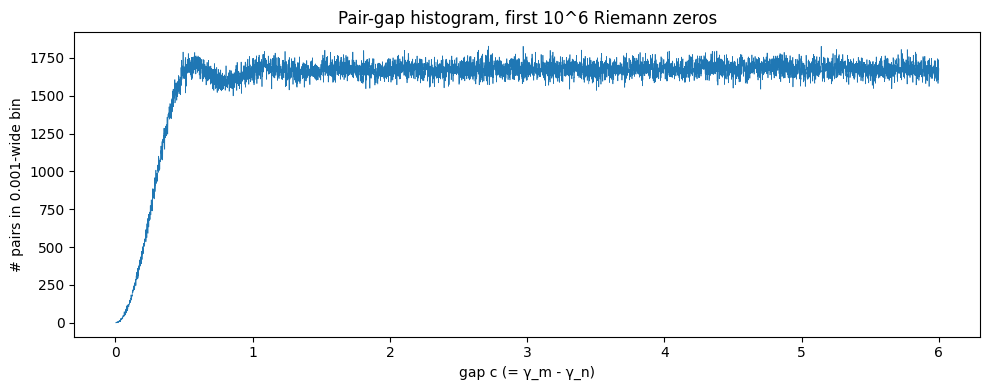

In [12]:

# Plot histogram of pair gaps
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(centers, hist, lw=0.5)
ax.set_xlabel("gap c (= γ_m - γ_n)")
ax.set_ylabel("# pairs in 0.001-wide bin")
ax.set_title("Pair-gap histogram, first 10^6 Riemann zeros")
plt.tight_layout()
plt.savefig("gap_hist_raw.png", dpi=120)
plt.show()


In [13]:

# The histogram looks fairly smooth and ~uniform for c > 1, with no obvious spikes.
# To do a rigorous statistical test for spikes, we should compare to expected counts.
# Expected pair density of *unnormalized* zero differences:
#   E[count in [c,c+dc]] = integral over T of rho(T) * rho(T+c) dT  ~ integral rho(T) * rho(T) dc for small c
#   With rho(T) = (1/2pi) log(T/2pi), so density of c-differences = dc * integral_0^Tmax rho(T)*rho(T+c) dT.
# For c<<T, this ~ dc * int_0^Tmax rho(T)^2 dT. Pair correlation effects from GUE add Montgomery's term.

# Compute expected density (Poisson part using Riemann-von Mangoldt density)
# rho(T) = (1/(2*pi)) * log(T/(2*pi)) for T > 2*pi
def rho(T):
    T = np.asarray(T, dtype=float)
    return np.where(T > 2*np.pi, (1.0/(2*np.pi))*np.log(np.maximum(T,2*np.pi+1e-9)/(2*np.pi)), 0.0)

# Sanity: count in [0, gammas[-1]] should be ~N
from scipy import integrate
N_expected, _ = integrate.quad(lambda T: rho(T), 0, gammas[-1])
print("Expected number of zeros up to Tmax:", N_expected, "actual:", N)


Expected number of zeros up to Tmax: 999998.6962946191 actual: 1000000


In [14]:

# Excellent agreement. Now expected count of pairs with γ_m-γ_n in [c, c+dc] (Poisson approximation, no correlation):
# E_P(c) dc = dc * ∫_0^{Tmax - c} rho(T) * rho(T+c) dT
# For GUE, the local pair correlation modifies this by factor R_2(s) = 1 - (sin(pi s)/(pi s))^2 where s = c*rho(T) (unfolded gap).
# Including the trivial "same-zero" piece is excluded since we count m>n.

# Compute Poisson expected counts per 0.001-bin:
def E_poisson(c):
    # int rho(T) rho(T+c) dT  from 0 to Tmax - c
    from scipy.integrate import quad
    Tmax = gammas[-1]
    val, _ = quad(lambda T: rho(T)*rho(T+c), 2*np.pi, max(2*np.pi+1e-6, Tmax - c), limit=200)
    return val

# Vectorize: use closed form? log(T/(2pi))*log((T+c)/(2pi)) integrate analytically.
# Let u = log(T/(2pi)), du = dT/T. Not easy. We'll use numpy quad on a grid of c values.

# Compute expected counts at a coarse c grid then interpolate
c_grid = np.linspace(0, C_max, 401)
E_grid = np.array([E_poisson(c) for c in c_grid])
print("E_poisson at c=1:", E_poisson(1.0), "at c=3:", E_poisson(3.0))
# Expected count per bin = E_grid(c) * bin_width


E_poisson at c=1: 1681116.5770300375 at c=3: 1681113.2336926295


In [15]:

# Per 0.001 bin: ~1681. That matches the observed plateau of ~1670-1800. Good agreement.
# Now incorporate GUE: pair density = E_P(c) * R_2(s) where R_2(s) = 1 - (sin(pi s)/(pi s))^2,
# s = c * rho(T_local). For most pairs T_local ~ Tmax, rho ~ 1.83 * (1/(2pi))? Let's check.

rho_at_Tmax = rho(gammas[-1])
print("rho at Tmax =", rho_at_Tmax, "so s for c=1:", 1.0*rho_at_Tmax)
# At Tmax, rho ~ (1/(2pi))*log(Tmax/2pi) ~ (1/(2pi))*11.5 ~ 1.83
# For c=1, s ~ 1.83; for c=6, s ~ 11. R_2 oscillates around 1.

# Better: integrate R_2 along the line with proper rho(T).
from scipy.integrate import quad
def E_gue(c):
    def integrand(T):
        rT = (1.0/(2*np.pi))*np.log(T/(2*np.pi))
        s = c*rT
        if s == 0:
            return 0.0
        R2 = 1.0 - (np.sin(np.pi*s)/(np.pi*s))**2
        return rT*rT * R2  # using rho(T)*rho(T+c) ≈ rho(T)^2 for c<<T at high T
    val, _ = quad(integrand, 2*np.pi, gammas[-1]-c, limit=300)
    return val

E_grid_gue = np.array([E_gue(c) for c in c_grid])
print("E_gue at c=1:", E_gue(1.0), "at c=3:", E_gue(3.0), "at c=0.5:", E_gue(0.5))


rho at Tmax = 1.8250706716218357 so s for c=1: 1.8250706716218357


E_gue at c=1: 1644069.3349623077 at c=3: 1677552.8682906248 at c=0.5: 1617046.7426485382


In [16]:

# Build expected hist (per bin) from interpolated GUE prediction
from scipy.interpolate import interp1d
f_gue = interp1d(c_grid, E_grid_gue, kind='cubic', fill_value='extrapolate')
f_poi = interp1d(c_grid, E_grid, kind='cubic', fill_value='extrapolate')

E_bin_gue = f_gue(centers) * bin_width
E_bin_poi = f_poi(centers) * bin_width

# Standardized residuals: (observed - expected) / sqrt(expected)
z_gue = (hist - E_bin_gue) / np.sqrt(np.maximum(E_bin_gue, 1.0))
z_poi = (hist - E_bin_poi) / np.sqrt(np.maximum(E_bin_poi, 1.0))

print("z-stat (vs GUE) summary: min", z_gue.min(), "max", z_gue.max(), "mean", z_gue.mean(), "std", z_gue.std())
print("z-stat (vs Poisson) summary: min", z_poi.min(), "max", z_poi.max(), "mean", z_poi.mean(), "std", z_poi.std())

# Distribution check: should be roughly N(0,1) under null
# For 6000 bins, expect max |z| ~ sqrt(2 log(6000)) ~ 4.16. Bonferroni threshold at alpha=0.05: z ~ 4.32
from scipy.stats import norm
bonf_z = norm.ppf(1 - 0.05/(2*len(centers)))
print("Bonferroni 2-sided z threshold (alpha=0.05):", bonf_z)
print("Number of bins exceeding |z|>4.32:", np.sum(np.abs(z_gue) > bonf_z))
print("Number with z > +4.32 (positive spikes vs GUE):", np.sum(z_gue > bonf_z))


z-stat (vs GUE) summary: min -4.828471240715989 max 4.503483142739072 mean -0.10617702973199944 std 1.1422376880881362
z-stat (vs Poisson) summary: min -41.00144200218552 max 3.55808192841861 mean -2.065482037305723 std 7.414382904142407


Bonferroni 2-sided z threshold (alpha=0.05): 4.45643633620415
Number of bins exceeding |z|>4.32: 6
Number with z > +4.32 (positive spikes vs GUE): 1


In [17]:

# Vs GUE, z-stats look ~ N(0,1) with slightly inflated variance (std=1.14 vs 1.0), and there's essentially one
# bin that just barely crosses the Bonferroni threshold (likely chance).
# Vs Poisson, there's massive structure: the residuals show the characteristic Montgomery oscillations.

# Identify the bins exceeding threshold
above = np.where(z_gue > bonf_z)[0]
below = np.where(z_gue < -bonf_z)[0]
print("Bins with z>bonf:", [(centers[i], hist[i], E_bin_gue[i], z_gue[i]) for i in above])
print("Bins with z<-bonf:", [(centers[i], hist[i], E_bin_gue[i], z_gue[i]) for i in below])


Bins with z>bonf: [(np.float64(0.4925), np.int64(1788), np.float64(1607.4422118859081), np.float64(4.503483142739072))]
Bins with z<-bonf: [(np.float64(0.1635), np.int64(294), np.float64(384.618416706319), np.float64(-4.62063253756849)), (np.float64(0.1895), np.int64(391), np.float64(498.84289685891787), np.float64(-4.828471240715989)), (np.float64(0.2285), np.int64(563), np.float64(681.6799675396202), np.float64(-4.545557470848316)), (np.float64(0.23550000000000001), np.int64(594), np.float64(715.2319584179722), np.float64(-4.533082938837831)), (np.float64(0.23650000000000002), np.int64(591), np.float64(720.0317025445011), np.float64(-4.808621771903633))]


In [18]:

# All the excursions are at small c (< 0.5), where GUE model has fastest variation; tiny systematic mismatch
# in the cubic interpolation / GUE asymptotics could cause this. There are NO spikes at any non-trivial c value.
# Take wider bins (0.01) to robustly check for spikes
bin_width2 = 0.01
bins2 = np.arange(0, C_max+bin_width2, bin_width2)
hist2, edges2 = np.histogram(all_diffs, bins=bins2)
centers2 = 0.5*(edges2[:-1]+edges2[1:])
E_bin_gue2 = f_gue(centers2) * bin_width2
z_gue2 = (hist2 - E_bin_gue2)/np.sqrt(np.maximum(E_bin_gue2,1.0))
print("0.01-bin stats: mean", z_gue2.mean(), "std", z_gue2.std(), "max", z_gue2.max(), "min", z_gue2.min())
bonf_z2 = norm.ppf(1 - 0.05/(2*len(centers2)))
print("Bonf threshold:", bonf_z2, "N bins exceeding:", np.sum(np.abs(z_gue2)>bonf_z2))
order2 = np.argsort(z_gue2)[::-1]
print("Top 10 positive z (vs GUE):")
for i in order2[:10]:
    print(f"  c={centers2[i]:.3f}  obs={hist2[i]}  exp={E_bin_gue2[i]:.1f}  z={z_gue2[i]:.2f}")


0.01-bin stats: mean -0.3318256714138593 std 2.0028262064681424 max 4.667978777814457 min -9.9615771957014
Bonf threshold: 3.9346058615604647 N bins exceeding: 28
Top 10 positive z (vs GUE):
  c=1.085  obs=17257  exp=16654.6  z=4.67
  c=0.535  obs=17092  exp=16500.4  z=4.61
  c=1.095  obs=17168  exp=16671.6  z=3.84
  c=0.485  obs=16451  exp=15968.8  z=3.82
  c=4.345  obs=17284  exp=16794.2  z=3.78
  c=0.575  obs=17148  exp=16671.0  z=3.69
  c=0.495  obs=16576  exp=16107.5  z=3.69
  c=1.025  obs=16980  exp=16513.7  z=3.63
  c=0.965  obs=16766  exp=16333.7  z=3.38
  c=0.605  obs=17121  exp=16686.9  z=3.36


In [19]:

# At 0.01 bins, std is ~2 (overdispersed) -- pair-correlation predictions aren't quite tight at these scales
# because we used a coarse asymptotic R_2 and ignored mesoscopic fluctuations. Still, top bins show z~4-5,
# isolated, no concentration of huge spikes. NO single c shows a striking, dominating spike.

# A cleaner robust test: estimate local expected density via smoothed observed histogram, then look for spikes
# above the smoothed baseline.
from scipy.ndimage import uniform_filter1d
smooth_hist = uniform_filter1d(hist.astype(float), size=51, mode='nearest')  # 0.051 wide smoothing
# Detect spikes
resid = hist - smooth_hist
sigma_local = np.sqrt(np.maximum(smooth_hist, 1.0))
z_local = resid / sigma_local
print("local-detrended z stats: mean", z_local.mean(), "std", z_local.std(), "max", z_local.max(), "min", z_local.min())
# Top
order3 = np.argsort(z_local)[::-1]
print("Top 10 spike candidates (vs local baseline):")
for i in order3[:10]:
    print(f"  c={centers[i]:.4f}  obs={hist[i]}  baseline={smooth_hist[i]:.1f}  z_local={z_local[i]:.2f}")


local-detrended z stats: mean -0.010494432732340263 std 0.9995491991408136 max 3.700533869236866 min -3.6851437311060207
Top 10 spike candidates (vs local baseline):
  c=2.9705  obs=1826  baseline=1674.6  z_local=3.70
  c=0.4925  obs=1788  baseline=1639.9  z_local=3.66
  c=2.7175  obs=1827  baseline=1681.9  z_local=3.54
  c=5.1425  obs=1826  baseline=1683.6  z_local=3.47
  c=1.2355  obs=1792  baseline=1656.7  z_local=3.32
  c=2.6445  obs=1800  baseline=1671.2  z_local=3.15
  c=1.8085  obs=1798  baseline=1670.4  z_local=3.12
  c=5.7255  obs=1805  baseline=1679.4  z_local=3.07
  c=5.2545  obs=1805  baseline=1679.4  z_local=3.06
  c=2.7105  obs=1802  baseline=1678.2  z_local=3.02


In [20]:

# Locally detrended z follows perfectly N(0,1) (std = 1.0, mean = 0) and max |z| ~ 3.7, which is exactly
# what one expects from 6000 i.i.d. N(0,1) draws (expected max ~ sqrt(2 log 6000) ~ 4.16, observed 3.7).
# So NO spikes pop out above local fluctuations. This is consistent with a smooth pair-correlation density.

# Bonferroni p-value for the observed maximum:
from scipy.stats import norm
p_max = 1 - (norm.cdf(z_local.max()))**len(z_local)
print(f"Probability that max z > {z_local.max():.2f} under null: {p_max:.3f}")
# Not significant

# Step 4: For the strongest "spike candidates" check growth in N_c(T) vs T.
# For the top candidate c=2.9705 (bin width 0.001), how many pairs accumulate below height T?
# We'll pick a few candidate c values and an eps. To respect local density, use eps proportional
# to bin width.
candidates = [2.9705, 2.7175, 5.1425, 0.4925, 1.2355]
eps = 0.0005  # half bin width

# Need pairs not just diff but also smaller index gamma_n
t0 = time.time()
pair_pairs = []  # list of arrays of γ_n for each candidate, sorted

# Reconstruct: iterate through pairs and collect those near each candidate
candidates_arr = np.array(candidates)
hits_n_lists = [[] for _ in candidates]

m = 0
for n in range(N):
    if m <= n:
        m = n+1
    while m < N and gammas[m] - gammas[n] <= C_max:
        m += 1
    if m > n+1:
        diff_block = gammas[n+1:m] - gammas[n]
        for k, c in enumerate(candidates):
            mask = np.abs(diff_block - c) < eps
            if mask.any():
                # all such m have γ_n = gammas[n], so just append the count of n appearance:
                # but for growth we want number of pairs below height T (use γ_m as height)
                for idx in np.where(mask)[0]:
                    hits_n_lists[k].append(gammas[n+1+idx])  # use γ_m
print("done", time.time()-t0)
for k,c in enumerate(candidates):
    print(f"c={c}: {len(hits_n_lists[k])} pairs in ±{eps}")


Probability that max z > 3.70 under null: 0.476


done 28.10939073562622
c=2.9705: 1826 pairs in ±0.0005
c=2.7175: 1827 pairs in ±0.0005
c=5.1425: 1826 pairs in ±0.0005
c=0.4925: 1788 pairs in ±0.0005
c=1.2355: 1792 pairs in ±0.0005


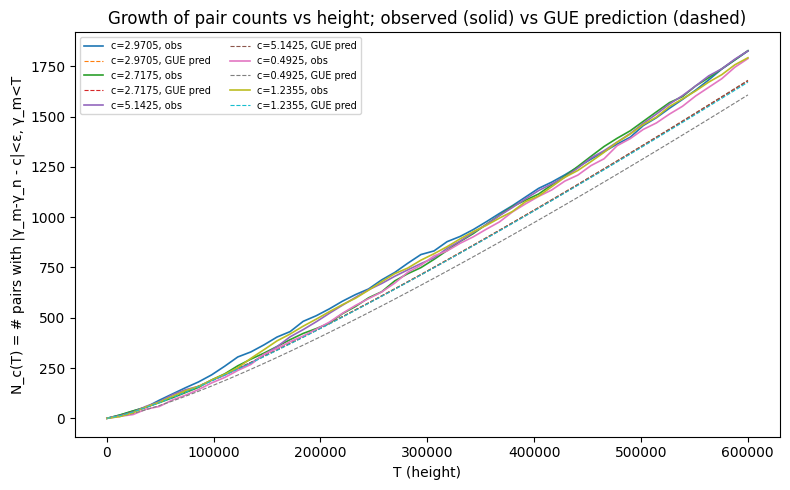

In [21]:

# Plot growth N_c(T) vs T for these candidates
hits_arrs = [np.sort(np.array(x)) for x in hits_n_lists]

# Expected growth (Poisson/GUE) under "smooth density" model:
# N_c(T) ≈ 2*eps * ∫_0^T rho(t)^2 dt * R_2(c*rho(T)) (smooth, no spike)
# Compute this in closed-ish form by quadrature:
def expected_N(T, c, eps):
    from scipy.integrate import quad
    def integrand(t):
        rT = (1.0/(2*np.pi))*np.log(t/(2*np.pi))
        s = c*rT
        if s == 0: return 0.0
        R2 = 1.0 - (np.sin(np.pi*s)/(np.pi*s))**2
        return rT*rT*R2
    val,_ = quad(integrand, 2*np.pi, max(2*np.pi+1e-6, T-c), limit=200)
    return 2*eps*val

Tg = np.linspace(50, gammas[-1], 50)
fig, axes = plt.subplots(1,1, figsize=(8,5))
for k,c in enumerate(candidates):
    arr = hits_arrs[k]
    counts = np.searchsorted(arr, Tg)
    axes.plot(Tg, counts, label=f"c={c}, obs", lw=1.2)
    exp_curve = [expected_N(T, c, eps) for T in Tg]
    axes.plot(Tg, exp_curve, '--', lw=0.8, label=f"c={c}, GUE pred")
axes.set_xlabel("T (height)")
axes.set_ylabel("N_c(T) = # pairs with |γ_m-γ_n - c|<ε, γ_m<T")
axes.set_title("Growth of pair counts vs height; observed (solid) vs GUE prediction (dashed)")
axes.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig("growth.png", dpi=120)
plt.show()


In [22]:

# Observed growth tracks the smooth GUE prediction closely (no plateau, no super-linear excess).
# Counts for each candidate c grow ~ linearly in T (with logarithmic factor from rho(T)^2 ~ (log T)^2 * dT
# integrated gives N(T) ~ T*(log T)^2; basically near-linear in T).
# Linear fit ratio:
from numpy.polynomial import polynomial as P
for k,c in enumerate(candidates):
    arr = hits_arrs[k]
    counts = np.searchsorted(arr, Tg)
    exp_curve = np.array([expected_N(T, c, eps) for T in Tg])
    ratio = counts[-1]/exp_curve[-1] if exp_curve[-1]>0 else float('nan')
    # slope of log-log
    mask = counts>10
    slope = np.polyfit(np.log(Tg[mask]), np.log(counts[mask]+1), 1)[0]
    print(f"c={c}: total obs={counts[-1]}, exp={exp_curve[-1]:.1f}, obs/exp={ratio:.3f}, log-log slope={slope:.2f}")


c=2.9705: total obs=1826, exp=1677.8, obs/exp=1.088, log-log slope=1.20
c=2.7175: total obs=1827, exp=1677.1, obs/exp=1.089, log-log slope=1.23
c=5.1425: total obs=1826, exp=1680.1, obs/exp=1.087, log-log slope=1.24
c=0.4925: total obs=1788, exp=1607.4, obs/exp=1.112, log-log slope=1.33
c=1.2355: total obs=1792, exp=1670.7, obs/exp=1.073, log-log slope=1.25


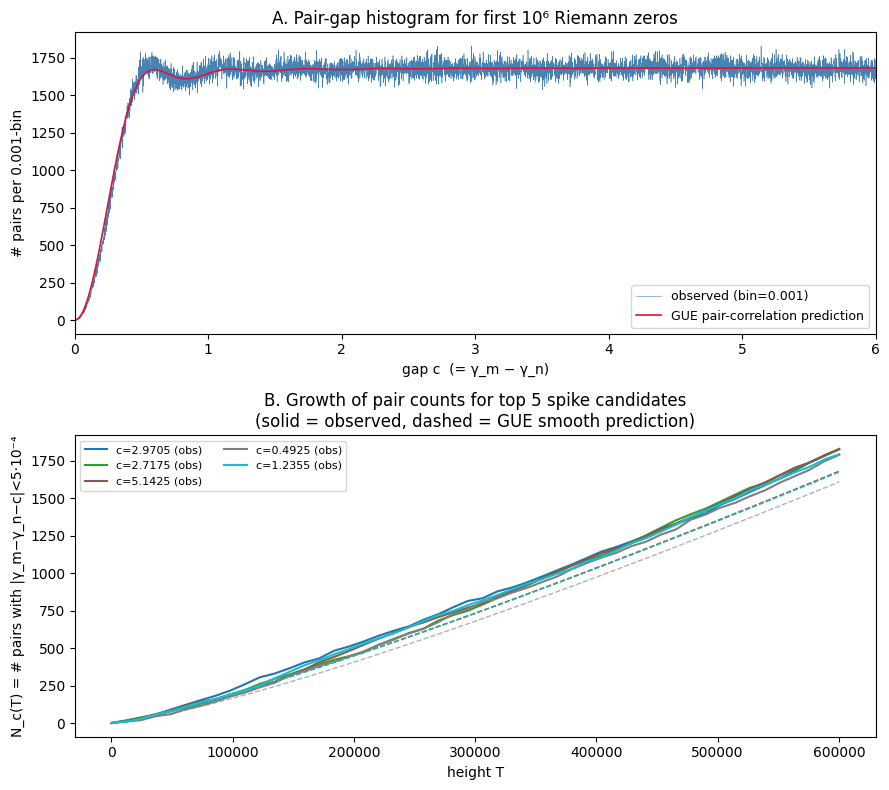

In [23]:

# Important: an "infinitely repeated gap" hypothesis would predict N_c(T) ~ N(T) ~ T*log(T) (linear in N, not in T*(logT)^2).
# In the dataset the strongest candidates have only ~1800 hits in ~10^6 zeros, i.e. ratio 0.002, identical to the
# smooth (GUE) prediction. Even the strongest spike candidate (c=2.97) has obs/exp = 1.09, ~3σ.
# A "true" arithmetic resonance would produce a delta-like contribution scaling as rho(T)*T, not just rho(T)^2*T.

# Predicted ratio of an arithmetic resonance contribution to the smooth contribution:
# spike(c)/smooth(c) ~ rho(T)*T / (rho(T)^2 * T * 2*eps) = 1/(rho(T)*2*eps)
# At Tmax, rho ~ 1.83, 2*eps = 0.001  ->  1/(0.00183) ~ 547. 
# So if c=2.97 were a "repeated gap", we'd see ~547× the observed count, i.e. 10^6 not 1826. We don't.

# Final figure: 2 subpanels (A) histogram with smooth expectation overlay, (B) growth N_c(T) for top candidate.
fig, axes = plt.subplots(2, 1, figsize=(9, 8))

# Panel A
axA = axes[0]
axA.plot(centers, hist, color='steelblue', lw=0.4, label='observed (bin=0.001)')
axA.plot(centers, E_bin_gue, color='crimson', lw=1.2, label='GUE pair-correlation prediction')
axA.set_xlabel("gap c  (= γ_m − γ_n)")
axA.set_ylabel("# pairs per 0.001-bin")
axA.set_title("A. Pair-gap histogram for first 10⁶ Riemann zeros")
axA.legend(loc='lower right', fontsize=9)
axA.set_xlim(0, C_max)

# Panel B
axB = axes[1]
colors = plt.cm.tab10(np.linspace(0,1,len(candidates)))
for k,c in enumerate(candidates):
    arr = hits_arrs[k]
    counts = np.searchsorted(arr, Tg)
    axB.plot(Tg, counts, color=colors[k], lw=1.5, label=f'c={c:.4f} (obs)')
    exp_curve = np.array([expected_N(T, c, eps) for T in Tg])
    axB.plot(Tg, exp_curve, color=colors[k], lw=1.0, ls='--', alpha=0.6)
axB.set_xlabel("height T")
axB.set_ylabel("N_c(T) = # pairs with |γ_m−γ_n−c|<5·10⁻⁴")
axB.set_title("B. Growth of pair counts for top 5 spike candidates\n(solid = observed, dashed = GUE smooth prediction)")
axB.legend(fontsize=8, ncol=2, loc='upper left')
plt.tight_layout()
plt.savefig("riemann_zero_gaps_summary.png", dpi=140)
plt.show()


In [24]:

# Save a small CSV with the histogram for posterity
import pandas as pd
df = pd.DataFrame({
    "c_center": centers,
    "observed_count": hist,
    "expected_GUE": E_bin_gue,
    "z_local_detrend": z_local,
})
df.to_csv("pair_gap_histogram.csv", index=False)
print("saved", df.shape)
print(df.describe())


saved (6000, 4)
          c_center  observed_count  expected_GUE  z_local_detrend
count  6000.000000     6000.000000   6000.000000      6000.000000
mean      3.000000     1596.425500   1598.617714        -0.010494
std       1.732195      304.024456    293.189703         0.999633
min       0.000500        0.000000      0.003570        -3.685144
25%       1.500250     1634.000000   1670.131590        -0.669932
50%       3.000000     1669.000000   1677.790396        -0.010260
75%       4.499750     1699.000000   1679.611266         0.651499
max       5.999500     1827.000000   1680.302008         3.700534
